<a href="https://colab.research.google.com/github/ClassNeuralNetwork/Regression-CaloricExpenditurePrediction/blob/main/caloricExpenditurePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
!pip install shap

In [65]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

In [66]:
path = kagglehub.dataset_download("fmendes/fmendesdat263xdemos")
print(os.listdir(path))

Using Colab cache for faster access to the 'fmendesdat263xdemos' dataset.
['exercise.csv', 'calories.csv']


##Preparar dados



In [67]:
df_exercise = pd.read_csv(os.path.join(path, "exercise.csv"))
df_calories = pd.read_csv(os.path.join(path, "calories.csv"))

df = pd.merge(df_exercise, df_calories, on="User_ID")
display(df.head())

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [68]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

X = df.drop(columns=['Calories', 'User_ID'])
y = df['Calories'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
feature_names = ['Idade', 'Altura', 'Peso', 'Duração', 'Batimentos', 'Temp. Corporal', 'Sexo (M=1)']

## Criando modelo


In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)), # 7 neuronios
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,345 (36.50 KB)

 Trainable params: 9,345 (36.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3564.5220 - val_loss: 131.2992
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 95.0930 - val_loss: 65.6494
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 44.5358 - val_loss: 29.3708
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 18.9131 - val_loss: 12.4082
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.5771 - val_loss: 5.8967
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.8994 - val_loss: 4.2025
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.4501 - val_loss: 2.8470
Epoch 8/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.6037 - val_loss: 2.1695
Epoch 9/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.0522 - val_loss: 1.7966
Epoch 10/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5883 - val_loss: 1.3652
Epoch 11/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3075 - val_loss: 1.1292
Epoch 12/100
300/300 ━━━━━━━━━

In [ ]:
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(y_pred.shape[0])

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MSE: {mse:.2f}\nR2: {r2:.4f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE: 0.23
R2: 0.9999
MAE: 0.38
RMSE: 0.48


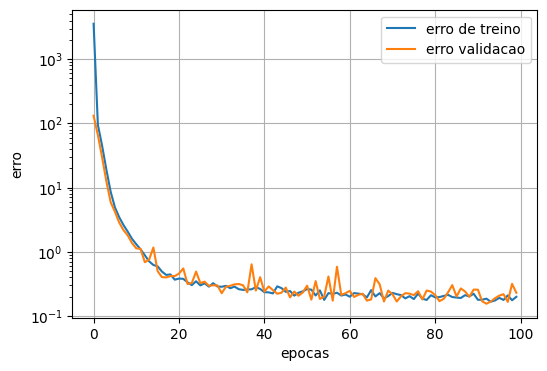

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='erro de treino')
plt.plot(history.history['val_loss'], label='erro validacao')
plt.xlabel('epocas')
plt.ylabel('erro')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
          #mlp-Nneuronios-Kepocas-V.keras
model.save('mlp-128-100-2.keras')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


# ia explicavel

In [79]:
background_data = shap.sample(X_train, 100)

explainer = shap.DeepExplainer(model, background_data)
shap_values = explainer.shap_values(X_test)

/usr/local/lib/python3.13/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_31
Received: inputs=['Tensor(shape=(100, 7))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_31
Received: inputs=['Tensor(shape=(200, 7))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_31
Received: inputs=['Tensor(shape=(3000, 7))']
  warnings.

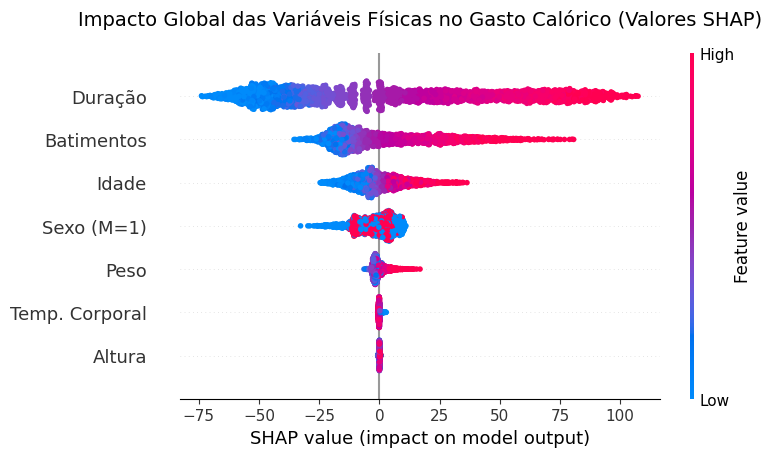

In [80]:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

if len(shap_values.shape) > 2:
    shap_values = np.squeeze(shap_values)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)

plt.title("Impacto Global das Variáveis Físicas no Gasto Calórico (Valores SHAP)", fontsize=14, pad=20)

plt.show()